In [86]:
%load_ext autoreload
%autoreload 2
import sys
import matplotlib.pyplot as plt
import numpy as np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [87]:
path = '../photom_redshift_distribution/'

In [88]:
file_data = 'COSMOS_QSO_WST_QSO_gsel_24.npz'
file_data_2 = 'COSMOS_QSO_WST_QSO_gsel_24_25.npz'
file_th = 'COSMOS_QSO_LF.npz'

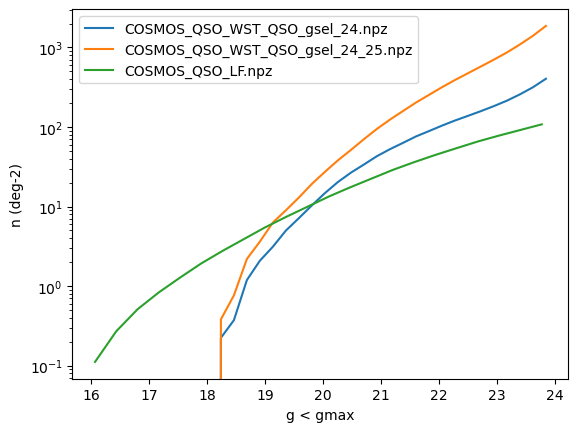

In [91]:
for f in [file_data , file_data_2, file_th]:
    N_zm = np.load(path + f)
    mag_centers = N_zm['mag_center']
    z_centers = N_zm['z_center']
    n_target_count = N_zm['object_count'] / N_zm['surface_deg2']
    plt.plot(mag_centers[(mag_centers < 24)*(mag_centers > 16)], np.cumsum(np.sum(n_target_count[:,(mag_centers < 24)*(mag_centers > 16)], axis=0)), label = f)
plt.yscale('log')
plt.ylabel('n (deg-2)')
plt.xlabel('g < gmax')
plt.legend()

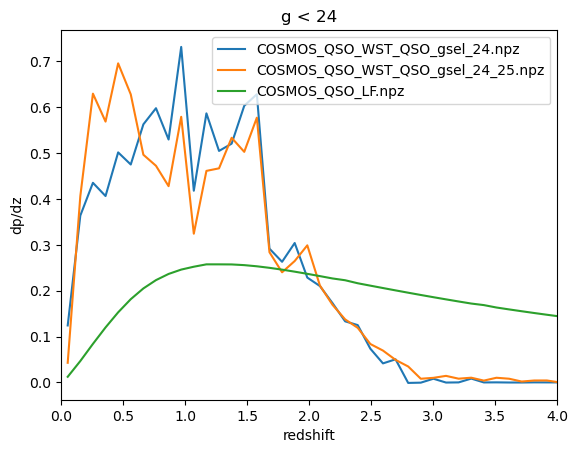

In [92]:
for f in [file_data , file_data_2, file_th]:
    N_zm = np.load(path + f)
    mag_centers = N_zm['mag_center']
    z_centers = N_zm['z_center']
    n_target_count = N_zm['object_count'] / N_zm['surface_deg2']
    nz = np.trapz(mag_centers[(mag_centers < 24)*(mag_centers > 16)], n_target_count[:,(mag_centers < 24)*(mag_centers > 16)],)
    nz *= 1/np.trapz(nz, z_centers)
    plt.plot(z_centers, nz, label = f)
#plt.yscale('log')
plt.xlim(0, 4)
plt.title('g < 24')
plt.ylabel('dp/dz')
plt.xlabel('redshift')
plt.legend()